In [1]:
import os
import json
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from transformers import LayoutLMTokenizer, LayoutLMForTokenClassification

In [2]:
TRAIN_IMG = r"C:\Users\acer\Downloads\OCR Project\SROIE2019\train\img"
TRAIN_BOX = r"C:\Users\acer\Downloads\OCR Project\SROIE2019\train\box"
TRAIN_ENTITY = r"C:\Users\acer\Downloads\OCR Project\SROIE2019\train\entities"

In [3]:
import os

image_files = sorted(
    os.listdir(TRAIN_IMG)
)

print("Number of images:", len(image_files))
print("First image:", image_files[0])

Number of images: 626
First image: X00016469612.jpg


In [4]:
import os

image_files = sorted(os.listdir(TRAIN_IMG))
box_files = sorted(os.listdir(TRAIN_BOX))
entity_files = sorted(os.listdir(TRAIN_ENTITY))

print("Number of images  :", len(image_files))
print("Number of boxes   :", len(box_files))
print("Number of entities:", len(entity_files))

print("\nFirst image  :", image_files[0])
print("First box    :", box_files[0])
print("First entity :", entity_files[0])

Number of images  : 626
Number of boxes   : 626
Number of entities: 626

First image  : X00016469612.jpg
First box    : X00016469612.txt
First entity : X00016469612.txt


In [6]:
tokenizer = LayoutLMTokenizer.from_pretrained(
    "microsoft/layoutlm-base-uncased"
)

print(type(tokenizer))

<class 'transformers.models.layoutlm.tokenization_layoutlm.LayoutLMTokenizer'>


c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
image_files = sorted(os.listdir(TRAIN_IMG))

print("Number of images:", len(image_files))
print("First image:", image_files[0])

Number of images: 626
First image: X00016469612.jpg


In [8]:
def read_box_file(file_path):

    words = []
    boxes = []

    with open(file_path, "r", encoding="utf-8") as f:

        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split(",")

            # First 8 values = bounding box coordinates
            coords = list(map(int, parts[:8]))

            # Remaining part = word/text
            word = ",".join(parts[8:]).strip()

            words.append(word)
            boxes.append(coords)

    return words, boxes

In [9]:
def read_entity_file(file_path):

    with open(file_path, "r", encoding="utf-8") as f:
        entity_data = json.load(f)

    return entity_data

In [10]:
import re

def normalize_text(text):
    text = text.upper()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [11]:
from difflib import SequenceMatcher

def create_labels(words, entity_data):

    labels = ["OTHER"] * len(words)

    entities = {
        "COMPANY": entity_data.get("company", ""),
        "DATE": entity_data.get("date", ""),
        "ADDRESS": entity_data.get("address", ""),
        "TOTAL": entity_data.get("total", "")
    }

    def clean(text):
        return normalize_text(text)

    for label, entity_text in entities.items():

        if not entity_text:
            continue

        entity_clean = clean(entity_text)
        entity_words = entity_text.split()

        best_score = 0
        best_start = None
        best_end = None

        # Search through groups of OCR words
        for start in range(len(words)):

            for end in range(
                start + 1,
                min(len(words), start + len(entity_words) + 3) + 1
            ):

                candidate = clean(" ".join(words[start:end]))

                if not candidate:
                    continue

                score = SequenceMatcher(
                    None,
                    entity_clean,
                    candidate
                ).ratio()

                if score > best_score:
                    best_score = score
                    best_start = start
                    best_end = end

        # Accept only reasonably strong matches
        if best_score >= 0.65:

            for i in range(best_start, best_end):
                labels[i] = label

    return labels

In [12]:
image_file = image_files[0]
file_name = os.path.splitext(image_file)[0]

box_file = os.path.join(TRAIN_BOX, file_name + ".txt")
entity_file = os.path.join(TRAIN_ENTITY, file_name + ".txt")

words, boxes = read_box_file(box_file)
entity_data = read_entity_file(entity_file)

print("ENTITY DATA:")
print(entity_data)

labels = create_labels(words, entity_data)

print("\n" + "=" * 70)
print("ENTITY DATA")
print("=" * 70)

for key, value in entity_data.items():
    print(f"{key.upper():10} : {value}")

print("\n" + "=" * 70)
print("WORDS AND LABELS")
print("=" * 70)

for word, label in zip(words, labels):
    print(f"{word:45} | {label}")

print("=" * 70)

ENTITY DATA:
{'company': 'BOOK TA .K (TAMAN DAYA) SDN BHD', 'date': '25/12/2018', 'address': 'NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.', 'total': '9.00'}

ENTITY DATA
COMPANY    : BOOK TA .K (TAMAN DAYA) SDN BHD
DATE       : 25/12/2018
ADDRESS    : NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
TOTAL      : 9.00

WORDS AND LABELS
TAN WOON YANN                                 | OTHER
BOOK TA .K(TAMAN DAYA) SDN BND                | COMPANY
789417-W                                      | OTHER
NO.53 55,57 & 59, JALAN SAGU 18,              | ADDRESS
TAMAN DAYA,                                   | ADDRESS
81100 JOHOR BAHRU,                            | ADDRESS
JOHOR.                                        | ADDRESS
DOCUMENT NO : TD01167104                      | OTHER
DATE:                                         | OTHER
25/12/2018 8:13:39 PM                         | OTHER
CASHIER:                                      | OTHER
MANIS     

In [13]:
from transformers import LayoutLMTokenizer

tokenizer = LayoutLMTokenizer.from_pretrained(
    "microsoft/layoutlm-base-uncased"
)

print(tokenizer)

LayoutLMTokenizer(name_or_path='microsoft/layoutlm-base-uncased', vocab_size=30522, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}


In [14]:
def normalize_boxes(boxes, image_width=1000, image_height=1000):

    normalized = []

    for box in boxes:

        x_coords = [box[0], box[2], box[4], box[6]]
        y_coords = [box[1], box[3], box[5], box[7]]

        x0 = min(x_coords)
        y0 = min(y_coords)
        x1 = max(x_coords)
        y1 = max(y_coords)

        normalized_box = [
            int(x0 / image_width * 1000),
            int(y0 / image_height * 1000),
            int(x1 / image_width * 1000),
            int(y1 / image_height * 1000)
        ]

        normalized.append(normalized_box)

    return normalized

In [15]:
from PIL import Image
import os

image_file = image_files[0]
image_path = os.path.join(TRAIN_IMG, image_file)

image = Image.open(image_path)

image_width, image_height = image.size

print("Image:", image_file)
print("Width:", image_width)
print("Height:", image_height)

Image: X00016469612.jpg
Width: 463
Height: 1013


In [16]:
def normalize_boxes(boxes, image_width, image_height):

    normalized = []

    for box in boxes:

        x_coords = [box[0], box[2], box[4], box[6]]
        y_coords = [box[1], box[3], box[5], box[7]]

        x0 = min(x_coords)
        y0 = min(y_coords)
        x1 = max(x_coords)
        y1 = max(y_coords)

        normalized_box = [
            int(x0 / image_width * 1000),
            int(y0 / image_height * 1000),
            int(x1 / image_width * 1000),
            int(y1 / image_height * 1000)
        ]

        normalized.append(normalized_box)

    return normalized

In [17]:
normalized_boxes = normalize_boxes(
    boxes,
    image_width,
    image_height
)

print("Original box:")
print(boxes[0])

print("\nNormalized box:")
print(normalized_boxes[0])

Original box:
[72, 25, 326, 25, 326, 64, 72, 64]

Normalized box:
[155, 24, 704, 63]


In [18]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    "microsoft/layoutlm-base-uncased",
    apply_ocr=False
)

print(type(processor))

<class 'transformers.models.layoutlm.tokenization_layoutlm_fast.LayoutLMTokenizerFast'>


c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [21]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/layoutlm-base-uncased",
    use_fast=True
)

print(type(tokenizer))
print("Tokenizer loaded successfully")

<class 'transformers.models.layoutlm.tokenization_layoutlm_fast.LayoutLMTokenizerFast'>
Tokenizer loaded successfully


In [22]:
encoding = tokenizer(
    words,
    is_split_into_words=True,
    truncation=True,
    padding="max_length",
    max_length=512,
    return_tensors="pt"
)

word_ids = encoding.word_ids(batch_index=0)

print("Input shape:", encoding["input_ids"].shape)
print("First 30 word IDs:")
print(word_ids[:30])

Input shape: torch.Size([1, 512])
First 30 word IDs:
[None, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3]


In [23]:
label2id = {
    "OTHER": 0,
    "COMPANY": 1,
    "DATE": 2,
    "ADDRESS": 3,
    "TOTAL": 4
}

id2label = {
    0: "OTHER",
    1: "COMPANY",
    2: "DATE",
    3: "ADDRESS",
    4: "TOTAL"
}

print(label2id)

{'OTHER': 0, 'COMPANY': 1, 'DATE': 2, 'ADDRESS': 3, 'TOTAL': 4}


In [24]:
token_boxes = []
token_labels = []

for word_id in word_ids:

    if word_id is None:
        # Special tokens such as [CLS] and [SEP]
        token_boxes.append([0, 0, 0, 0])
        token_labels.append(-100)

    else:
        # Give the token its original word's box
        token_boxes.append(normalized_boxes[word_id])

        # Give the token its original word's label
        token_labels.append(
            label2id[labels[word_id]]
        )

print("Number of token boxes:", len(token_boxes))
print("Number of token labels:", len(token_labels))

print("\nFirst 20 boxes:")
print(token_boxes[:20])

print("\nFirst 20 labels:")
print(token_labels[:20])

Number of token boxes: 512
Number of token labels: 512

First 20 boxes:
[[0, 0, 0, 0], [155, 24, 704, 63], [155, 24, 704, 63], [155, 24, 704, 63], [155, 24, 704, 63], [155, 24, 704, 63], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119], [107, 80, 950, 119]]

First 20 labels:
[-100, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [25]:
encoding["bbox"] = torch.tensor(
    [token_boxes],
    dtype=torch.long
)

encoding["labels"] = torch.tensor(
    [token_labels],
    dtype=torch.long
)



print("\nInput IDs:", encoding["input_ids"].shape)
print("Attention mask:", encoding["attention_mask"].shape)
print("BBox:", encoding["bbox"].shape)
print("Labels:", encoding["labels"].shape)


Input IDs: torch.Size([1, 512])
Attention mask: torch.Size([1, 512])
BBox: torch.Size([1, 512, 4])
Labels: torch.Size([1, 512])


In [26]:
class InvoiceDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        image_path,
        box_path,
        entity_path,
        tokenizer
    ):
        self.image_path = image_path
        self.box_path = box_path
        self.entity_path = entity_path
        self.tokenizer = tokenizer

        self.image_files = [
            f for f in os.listdir(image_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        # -----------------------------
        # 1. Get file name
        # -----------------------------
        image_file = self.image_files[idx]
        file_name = os.path.splitext(image_file)[0]

        # -----------------------------
        # 2. File paths
        # -----------------------------
        box_file = os.path.join(
            self.box_path,
            file_name + ".txt"
        )

        entity_file = os.path.join(
            self.entity_path,
            file_name + ".txt"
        )

        # -----------------------------
        # 3. Read OCR words + boxes
        # -----------------------------
        words, boxes = read_box_file(box_file)

        # -----------------------------
        # 4. Read entities
        # -----------------------------
        entity_data = read_entity_file(entity_file)

        # -----------------------------
        # 5. Create word-level labels
        # -----------------------------
        labels = create_labels(
            words,
            entity_data
        )

        # -----------------------------
        # 6. Get actual image size
        # -----------------------------
        image = Image.open(
            os.path.join(
                self.image_path,
                image_file
            )
        )

        image_width, image_height = image.size

        # -----------------------------
        # 7. Normalize bounding boxes
        # -----------------------------
        normalized_boxes = normalize_boxes(
            boxes,
            image_width,
            image_height
        )

        # -----------------------------
        # 8. Tokenize words
        # -----------------------------
        encoding = self.tokenizer(
            words,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=512,
            return_tensors="pt"
        )

        # -----------------------------
        # 9. Get word IDs
        # -----------------------------
        word_ids = encoding.word_ids(
            batch_index=0
        )

        token_boxes = []
        token_labels = []

        # -----------------------------
        # 10. Align boxes + labels
        # -----------------------------
        for word_id in word_ids:

            if word_id is None:

                token_boxes.append(
                    [0, 0, 0, 0]
                )

                token_labels.append(-100)

            else:

                token_boxes.append(
                    normalized_boxes[word_id]
                )

                token_labels.append(
                    label2id[labels[word_id]]
                )

        # -----------------------------
        # 11. Add bbox + labels
        # -----------------------------
        encoding["bbox"] = torch.tensor(
            [token_boxes],
            dtype=torch.long
        )

        encoding["labels"] = torch.tensor(
            [token_labels],
            dtype=torch.long
        )

        # Remove batch dimension
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "bbox": encoding["bbox"].squeeze(0),
            "labels": encoding["labels"].squeeze(0)
        }

In [27]:
dataset = InvoiceDataset(
    TRAIN_IMG,
    TRAIN_BOX,
    TRAIN_ENTITY,
    tokenizer
)

print("Number of invoices:", len(dataset))

Number of invoices: 626


In [28]:
sample = dataset[0]

print("Input IDs:", sample["input_ids"].shape)
print("Attention mask:", sample["attention_mask"].shape)
print("BBox:", sample["bbox"].shape)
print("Labels:", sample["labels"].shape)

Input IDs: torch.Size([512])
Attention mask: torch.Size([512])
BBox: torch.Size([512, 4])
Labels: torch.Size([512])


In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("Number of batches:", len(train_loader))

Number of batches: 157


In [30]:
batch = next(iter(train_loader))

print("Input IDs:", batch["input_ids"].shape)
print("Attention mask:", batch["attention_mask"].shape)
print("BBox:", batch["bbox"].shape)
print("Labels:", batch["labels"].shape)

Input IDs: torch.Size([4, 512])
Attention mask: torch.Size([4, 512])
BBox: torch.Size([4, 512, 4])
Labels: torch.Size([4, 512])


In [31]:
from transformers import LayoutLMForTokenClassification

model = LayoutLMForTokenClassification.from_pretrained(
    "microsoft/layoutlm-base-uncased",
    num_labels=5
)

print("LayoutLM loaded successfully")

Some weights of LayoutLMForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlm-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LayoutLM loaded successfully


In [32]:
batch = next(iter(train_loader))

outputs = model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"],
    bbox=batch["bbox"],
    labels=batch["labels"]
)

print("Loss:", outputs.loss)
print("Logits shape:", outputs.logits.shape)

Loss: tensor(1.4769, grad_fn=<NllLossBackward0>)
Logits shape: torch.Size([4, 512, 5])


In [33]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=5e-5
)

print("Optimizer ready")

Optimizer ready


In [34]:
num_epochs = 3

print("Number of epochs:", num_epochs)

Number of epochs: 3


In [35]:
batch = next(iter(train_loader))

print("Batch loaded")

model.train()

optimizer.zero_grad()

outputs = model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"],
    bbox=batch["bbox"],
    labels=batch["labels"]
)

print("Forward pass completed")
print("Loss:", outputs.loss.item())

outputs.loss.backward()

print("Backward pass completed")

optimizer.step()

print("Optimizer step completed")

Batch loaded
Forward pass completed
Loss: 1.502931833267212
Backward pass completed
Optimizer step completed


In [36]:
import os
import torch

os.makedirs("saved_model", exist_ok=True)

checkpoint_path = "saved_model/checkpoint.pth"

torch.save(
    {
        "epoch": 2,              # Epoch 3 completed
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "loss": 0.0060            # Your last reported loss
    },
    checkpoint_path
)

print("================================")
print("CHECKPOINT CREATED SUCCESSFULLY")
print("Completed Epochs : 3")
print("Checkpoint       :", checkpoint_path)
print("================================")

CHECKPOINT CREATED SUCCESSFULLY
Completed Epochs : 3
Checkpoint       : saved_model/checkpoint.pth


In [37]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Device:", device)

Device: cpu


In [38]:
from tqdm.auto import tqdm
import torch
import os

# ============================================================
# SETTINGS
# ============================================================

start_epoch = 3       # Epochs 1, 2, 3 already completed
num_epochs = 5        # Total epochs wanted = 5

checkpoint_path = "saved_model/checkpoint.pth"

os.makedirs("saved_model", exist_ok=True)


# ============================================================
# CONTINUE TRAINING
# ============================================================

for epoch in range(start_epoch, num_epochs):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{num_epochs}"
    )

    for batch in progress_bar:

        # -------------------------
        # Move batch to device
        # -------------------------

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        # -------------------------
        # Clear gradients
        # -------------------------

        optimizer.zero_grad()

        # -------------------------
        # Forward pass
        # -------------------------

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            bbox=batch["bbox"],
            labels=batch["labels"]
        )

        # -------------------------
        # Loss
        # -------------------------

        loss = outputs.loss

        # -------------------------
        # Backpropagation
        # -------------------------

        loss.backward()

        optimizer.step()

        # -------------------------
        # Track loss
        # -------------------------

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    # ========================================================
    # AVERAGE LOSS
    # ========================================================

    average_loss = (
        total_loss / len(train_loader)
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs}"
        f" - Average Loss: {average_loss:.4f}"
    )

    # ========================================================
    # SAVE CHECKPOINT AFTER EVERY EPOCH
    # ========================================================

    torch.save(
        {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "loss": average_loss
        },
        checkpoint_path
    )

    print(
        f"Checkpoint saved after "
        f"epoch {epoch + 1}"
    )


# ============================================================
# TRAINING FINISHED
# ============================================================

print()
print("=" * 55)
print("TRAINING COMPLETED")
print("=" * 55)
print("Epochs 1-3 : Already completed")
print("Epochs 4-5 : Completed now")
print("Total      : 5 epochs")
print("=" * 55)

Epoch 4/5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 4/5 - Average Loss: 0.1403
Checkpoint saved after epoch 4


Epoch 5/5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 5/5 - Average Loss: 0.0357
Checkpoint saved after epoch 5

TRAINING COMPLETED
Epochs 1-3 : Already completed
Epochs 4-5 : Completed now
Total      : 5 epochs


In [39]:
save_path = "layoutlm_invoice_model"

model.save_pretrained(save_path)

print("Model saved successfully!")

Model saved successfully!


In [40]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 500
Testing samples: 126


In [41]:
test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

print("Number of test batches:", len(test_loader))

Number of test batches: 32


In [42]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            bbox=batch["bbox"],
            labels=batch["labels"]
        )

        predictions = torch.argmax(outputs.logits, dim=-1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

print("Testing completed!")

Testing completed!


In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

true_labels = []
pred_labels = []

for predictions, labels in zip(all_predictions, all_labels):
    for pred, label in zip(predictions, labels):

        if label != -100:
            true_labels.append(label)
            pred_labels.append(pred)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted",
    zero_division=0
)

accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Token-level Accuracy:", accuracy)

Precision: 0.9972486616997269
Recall: 0.9972283992394212
F1-score: 0.9972348675251235
Token-level Accuracy: 0.9972283992394212


In [44]:
from collections import Counter

print("True label distribution:")
print(Counter(true_labels))

print("\nPredicted label distribution:")
print(Counter(pred_labels))

True label distribution:
Counter({np.int64(0): 25620, np.int64(3): 3206, np.int64(1): 1236, np.int64(2): 564, np.int64(4): 403})

Predicted label distribution:
Counter({np.int64(0): 25621, np.int64(3): 3186, np.int64(1): 1237, np.int64(2): 573, np.int64(4): 412})


In [45]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    pred_labels,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

           0     0.9984    0.9984    0.9984     25620
           1     0.9887    0.9895    0.9891      1236
           2     0.9825    0.9982    0.9903       564
           3     1.0000    0.9938    0.9969      3206
           4     0.9490    0.9702    0.9595       403

    accuracy                         0.9972     31029
   macro avg     0.9837    0.9900    0.9868     31029
weighted avg     0.9972    0.9972    0.9972     31029



In [46]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(true_labels, pred_labels)

print(pd.DataFrame(
    cm,
    index=[f"True {i}" for i in range(5)],
    columns=[f"Pred {i}" for i in range(5)]
))

        Pred 0  Pred 1  Pred 2  Pred 3  Pred 4
True 0   25580      14       5       0      21
True 1      13    1223       0       0       0
True 2       1       0     563       0       0
True 3      15       0       5    3186       0
True 4      12       0       0       0     391


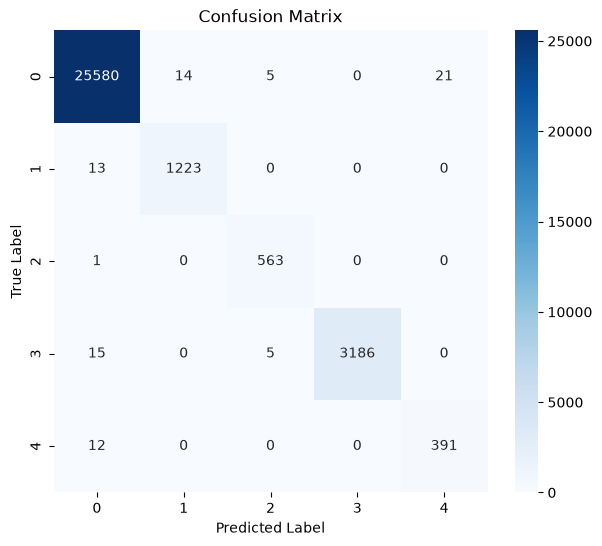

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1", "2", "3", "4"],
    yticklabels=["0", "1", "2", "3", "4"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [48]:
test_image = os.path.join(
    TRAIN_IMG,
    image_files[0]
)

print(test_image)

C:\Users\acer\Downloads\OCR Project\SROIE2019\train\img\X00016469612.jpg


In [49]:
import os
import json
import torch

# Choose an invoice from the dataset
idx = 25

# Get the image filename
image_file = dataset.image_files[idx]

# Remove .jpg / .png extension
file_name = os.path.splitext(image_file)[0]

# Find the matching Box file
box_file = os.path.join(
    dataset.box_path,
    file_name + ".txt"
)

# Read OCR words and bounding boxes
words, boxes = read_box_file(box_file)

print("Number of words:", len(words))
print("First few words:", words[:10])

Number of words: 71
First few words: ['TEO HENG STATIONERY & BOOKS', '(001451637-M)', 'NO. 53, JALAN BESAR, 45600 BATANG BERJUNTAI', 'SELANGOR DARUL EHSAN', 'TEL : 03-3271 9872', 'GST NO. : 000689913856', 'SIMPLIFIED TAX INVOICE', 'CASH', 'RECEIPT NO. : CS1801/27037', 'DATE : 23/01/2018']


In [50]:
print(boxes[0])
print("Number of values:", len(boxes[0]))

[723, 557, 1451, 557, 1451, 618, 723, 618]
Number of values: 8


In [51]:
print("Image size:", image.size)
print("First 5 original boxes:")

for box in boxes[:5]:
    print(box)

print("\nFirst 5 normalized boxes:")

for box in normalized_boxes[:5]:
    print(box)

Image size: (463, 1013)
First 5 original boxes:
[723, 557, 1451, 557, 1451, 618, 723, 618]
[995, 623, 1185, 623, 1185, 651, 995, 651]
[789, 657, 1390, 657, 1390, 685, 789, 685]
[936, 697, 1243, 697, 1243, 720, 936, 720]
[839, 731, 1065, 731, 1065, 756, 839, 756]

First 5 normalized boxes:
[155, 24, 704, 63]
[107, 80, 950, 119]
[442, 119, 615, 137]
[237, 142, 827, 160]
[414, 166, 645, 184]


In [52]:
max_x = max(
    max(box[0], box[2], box[4], box[6])
    for box in boxes
)

max_y = max(
    max(box[1], box[3], box[5], box[7])
    for box in boxes
)

print("Box coordinate width:", max_x)
print("Box coordinate height:", max_y)

Box coordinate width: 1516
Box coordinate height: 2802


In [53]:
normalized_boxes = []

for box in boxes:
    x1, y1, x2, y2, x3, y3, x4, y4 = box

    left = min(x1, x2, x3, x4)
    top = min(y1, y2, y3, y4)
    right = max(x1, x2, x3, x4)
    bottom = max(y1, y2, y3, y4)

    normalized_box = [
        int(1000 * left / max_x),
        int(1000 * top / max_y),
        int(1000 * right / max_x),
        int(1000 * bottom / max_y)
    ]

    normalized_boxes.append(normalized_box)

print("First 5 normalized boxes:")

for box in normalized_boxes[:5]:
    print(box)

First 5 normalized boxes:
[476, 198, 957, 220]
[656, 222, 781, 232]
[520, 234, 916, 244]
[617, 248, 819, 256]
[553, 260, 702, 269]


In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [55]:
encoding = tokenizer(
    words,
    is_split_into_words=True,
    truncation=True,
    padding="max_length",
    max_length=512,
    return_tensors="pt"
)

input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

word_ids = encoding.word_ids(batch_index=0)

token_boxes = []

for word_id in word_ids:
    if word_id is None:
        token_boxes.append([0, 0, 0, 0])
    else:
        token_boxes.append(normalized_boxes[word_id])

bbox = torch.tensor(
    [token_boxes],
    dtype=torch.long
).to(device)

print("Input IDs:", input_ids.shape)
print("Attention mask:", attention_mask.shape)
print("BBox:", bbox.shape)

Input IDs: torch.Size([1, 512])
Attention mask: torch.Size([1, 512])
BBox: torch.Size([1, 512, 4])


In [56]:
model.eval()

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        bbox=bbox
    )

predictions = torch.argmax(outputs.logits, dim=-1)[0]

print("Prediction completed!")

Prediction completed!


In [57]:
id2label = {
    0: "OTHER",
    1: "COMPANY",
    2: "DATE",
    3: "ADDRESS",
    4: "TOTAL"
}

word_ids = encoding.word_ids(batch_index=0)

word_predictions = {}

for token_index, word_id in enumerate(word_ids):

    if word_id is None:
        continue

    if word_id >= len(words):
        continue

    # Keep the first prediction for each original word
    if word_id not in word_predictions:
        word_predictions[word_id] = predictions[token_index].item()


result = {
    "company": "",
    "date": "",
    "address": "",
    "total": ""
}

for word_id, label_id in word_predictions.items():

    label = id2label[label_id]
    word = words[word_id]

    if label == "COMPANY":
        result["company"] += word + " "

    elif label == "DATE":
        result["date"] += word + " "

    elif label == "ADDRESS":
        result["address"] += word + " "

    elif label == "TOTAL":
        result["total"] += word + " "


for key in result:
    result[key] = result[key].strip()

print(json.dumps(result, indent=4))

{
    "company": "TEO HENG STATIONERY & BOOKS",
    "date": "DATE : 23/01/2018",
    "address": "NO. 53, JALAN BESAR, 45600 BATANG BERJUNTAI SELANGOR DARUL EHSAN",
    "total": "18.00"
}


In [58]:
import re

# Remove "DATE :" from the beginning
result["date"] = re.sub(
    r"^\s*DATE\s*:\s*",
    "",
    result["date"],
    flags=re.IGNORECASE
)

# Remove time (HH:MM) from the end
result["date"] = re.sub(
    r"\s+\d{1,2}:\d{2}\s*$",
    "",
    result["date"]
)

print(json.dumps(result, indent=4))

{
    "company": "TEO HENG STATIONERY & BOOKS",
    "date": "23/01/2018",
    "address": "NO. 53, JALAN BESAR, 45600 BATANG BERJUNTAI SELANGOR DARUL EHSAN",
    "total": "18.00"
}


In [59]:
#Choose another invoice

idx = 30

image_file = dataset.image_files[idx]
file_name = os.path.splitext(image_file)[0]

box_file = os.path.join(
    dataset.box_path,
    file_name + ".txt"
)

words, boxes = read_box_file(box_file)

print("Testing invoice:", image_file)
print("Number of words:", len(words))

Testing invoice: X51005433492.jpg
Number of words: 39


In [60]:
#Get the image dimensions and normalize its boxes

image_path = os.path.join(
    TRAIN_IMG,
    image_file
)

image = Image.open(image_path)

width, height = image.size

normalized_boxes = []

for box in boxes:
    x1, y1, x2, y2, x3, y3, x4, y4 = box

    left = min(x1, x2, x3, x4)
    top = min(y1, y2, y3, y4)
    right = max(x1, x2, x3, x4)
    bottom = max(y1, y2, y3, y4)

    normalized_boxes.append([
        int(1000 * left / width),
        int(1000 * top / height),
        int(1000 * right / width),
        int(1000 * bottom / height)
    ])

In [61]:
#Tokenize it

encoding = tokenizer(
    words,
    is_split_into_words=True,
    truncation=True,
    padding="max_length",
    max_length=512,
    return_tensors="pt"
)

input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

word_ids = encoding.word_ids(batch_index=0)

token_boxes = []

for word_id in word_ids:
    if word_id is None:
        token_boxes.append([0, 0, 0, 0])
    else:
        token_boxes.append(normalized_boxes[word_id])

bbox = torch.tensor(
    [token_boxes],
    dtype=torch.long
).to(device)

print("Input IDs:", input_ids.shape)
print("BBox:", bbox.shape)

Input IDs: torch.Size([1, 512])
BBox: torch.Size([1, 512, 4])


In [62]:
#Predict

model.eval()

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        bbox=bbox
    )

predictions = torch.argmax(outputs.logits, dim=-1)[0]

print("Prediction completed!")

Prediction completed!


In [63]:
#Extract the fields

id2label = {
    0: "OTHER",
    1: "COMPANY",
    2: "DATE",
    3: "ADDRESS",
    4: "TOTAL"
}

word_ids = encoding.word_ids(batch_index=0)

word_predictions = {}

for token_index, word_id in enumerate(word_ids):

    if word_id is None or word_id >= len(words):
        continue

    if word_id not in word_predictions:
        word_predictions[word_id] = predictions[token_index].item()

result = {
    "company": "",
    "date": "",
    "address": "",
    "total": ""
}

for word_id, label_id in word_predictions.items():

    label = id2label[label_id]
    word = words[word_id]

    if label == "COMPANY":
        result["company"] += word + " "
    elif label == "DATE":
        result["date"] += word + " "
    elif label == "ADDRESS":
        result["address"] += word + " "
    elif label == "TOTAL":
        result["total"] += word + " "

for key in result:
    result[key] = result[key].strip()

# Clean DATE:
result["date"] = re.sub(
    r"^\s*DATE\s*:\s*",
    "",
    result["date"],
    flags=re.IGNORECASE
)

print(json.dumps(result, indent=4))

{
    "company": "UNIHAKKA INTERNATIONAL SDN BHD",
    "date": "05 MAR 2018 18:24",
    "address": "12, JALAN TAMPOI 7/4,KAWASAN PERINDUSTRIAN TAMPOI,81200 JOHOR BAHRU,JOHOR",
    "total": "$8.20"
}


In [64]:
# Remove time (HH:MM) from the end
result["date"] = re.sub(
    r"\s+\d{1,2}:\d{2}\s*$",
    "",
    result["date"]
)

print(json.dumps(result, indent=4))

{
    "company": "UNIHAKKA INTERNATIONAL SDN BHD",
    "date": "05 MAR 2018",
    "address": "12, JALAN TAMPOI 7/4,KAWASAN PERINDUSTRIAN TAMPOI,81200 JOHOR BAHRU,JOHOR",
    "total": "$8.20"
}


In [65]:
TEST_IMG = r"C:\Users\acer\Downloads\OCR Project\SROIE2019\test\img"
TEST_BOX = r"C:\Users\acer\Downloads\OCR Project\SROIE2019\test\box"
TEST_ENTITY = r"C:\Users\acer\Downloads\OCR Project\SROIE2019\test\entities"

print("Test images:", len(os.listdir(TEST_IMG)))
print("Test boxes:", len(os.listdir(TEST_BOX)))
print("Test entities:", len(os.listdir(TEST_ENTITY)))

Test images: 347
Test boxes: 347
Test entities: 347


In [66]:
test_image_files = sorted(os.listdir(TEST_IMG))

test_idx = 0

test_image_file = test_image_files[test_idx]
test_file_name = os.path.splitext(test_image_file)[0]

print("Testing unseen invoice:", test_image_file)
print("Corresponding box file:", test_file_name + ".txt")
print("Corresponding entity file:", test_file_name + ".txt")

Testing unseen invoice: X00016469670.jpg
Corresponding box file: X00016469670.txt
Corresponding entity file: X00016469670.txt


In [67]:
test_box_file = os.path.join(
    TEST_BOX,
    test_file_name + ".txt"
)

test_words, test_boxes = read_box_file(test_box_file)

print("Number of words:", len(test_words))
print("First 10 words:")
print(test_words[:10])

Number of words: 47
First 10 words:
['TAN CHAY YEE', '*** COPY ***', 'OJC MARKETING SDN BHD', 'ROC NO: 538358-H', 'NO 2 & 4, JALAN BAYU 4,', 'BANDAR SERI ALAM,', '81750 MASAI, JOHOR', 'TEL:07-388 2218 FAX:07-388 8218', 'EMAIL:NG@OJCGROUP.COM', 'TAX INVOICE']


In [68]:
test_max_x = max(
    max(box[0], box[2], box[4], box[6])
    for box in test_boxes
)

test_max_y = max(
    max(box[1], box[3], box[5], box[7])
    for box in test_boxes
)

print("Test box coordinate width:", test_max_x)
print("Test box coordinate height:", test_max_y)

Test box coordinate width: 383
Test box coordinate height: 886


In [69]:
test_normalized_boxes = []

for box in test_boxes:
    x1, y1, x2, y2, x3, y3, x4, y4 = box

    left = min(x1, x2, x3, x4)
    top = min(y1, y2, y3, y4)
    right = max(x1, x2, x3, x4)
    bottom = max(y1, y2, y3, y4)

    normalized_box = [
        int(1000 * left / test_max_x),
        int(1000 * top / test_max_y),
        int(1000 * right / test_max_x),
        int(1000 * bottom / test_max_y)
    ]

    test_normalized_boxes.append(normalized_box)

print("First 5 normalized boxes:")

for box in test_normalized_boxes[:5]:
    print(box)

First 5 normalized boxes:
[255, 29, 838, 74]
[360, 107, 728, 135]
[208, 134, 859, 158]
[336, 160, 749, 180]
[271, 183, 798, 205]


In [70]:
encoding = tokenizer(
    test_words,
    is_split_into_words=True,
    truncation=True,
    padding="max_length",
    max_length=512,
    return_tensors="pt"
)

input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

word_ids = encoding.word_ids(batch_index=0)

token_boxes = []

for word_id in word_ids:
    if word_id is None:
        token_boxes.append([0, 0, 0, 0])
    else:
        token_boxes.append(test_normalized_boxes[word_id])

bbox = torch.tensor(
    [token_boxes],
    dtype=torch.long
).to(device)

print("Input IDs:", input_ids.shape)
print("Attention mask:", attention_mask.shape)
print("BBox:", bbox.shape)

Input IDs: torch.Size([1, 512])
Attention mask: torch.Size([1, 512])
BBox: torch.Size([1, 512, 4])


In [71]:
model.eval()

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        bbox=bbox
    )

predictions = torch.argmax(outputs.logits, dim=-1)[0]

print("Prediction completed!")

from collections import Counter

print("Prediction distribution:")
print(Counter(predictions.cpu().numpy().tolist()))

Prediction completed!
Prediction distribution:
Counter({0: 478, 3: 23, 1: 8, 4: 3})


In [72]:
id2label = {
    0: "OTHER",
    1: "COMPANY",
    2: "DATE",
    3: "ADDRESS",
    4: "TOTAL"
}

word_ids = encoding.word_ids(batch_index=0)

word_predictions = {}

for token_index, word_id in enumerate(word_ids):

    if word_id is None:
        continue

    if word_id >= len(test_words):
        continue

    if word_id not in word_predictions:
        word_predictions[word_id] = predictions[token_index].item()


result = {
    "company": "",
    "date": "",
    "address": "",
    "total": ""
}

for word_id, label_id in word_predictions.items():

    label = id2label[label_id]
    word = test_words[word_id]

    if label == "COMPANY":
        result["company"] += word + " "

    elif label == "DATE":
        result["date"] += word + " "

    elif label == "ADDRESS":
        result["address"] += word + " "

    elif label == "TOTAL":
        result["total"] += word + " "


for key in result:
    result[key] = result[key].strip()

print(json.dumps(result, indent=4))

{
    "company": "OJC MARKETING SDN BHD",
    "date": "",
    "address": "NO 2 & 4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR",
    "total": "193.00"
}


In [73]:
for i, word in enumerate(test_words):
    print(i, ":", word)

0 : TAN CHAY YEE
1 : *** COPY ***
2 : OJC MARKETING SDN BHD
3 : ROC NO: 538358-H
4 : NO 2 & 4, JALAN BAYU 4,
5 : BANDAR SERI ALAM,
6 : 81750 MASAI, JOHOR
7 : TEL:07-388 2218 FAX:07-388 8218
8 : EMAIL:NG@OJCGROUP.COM
9 : TAX INVOICE
10 : INVOICE NO
11 : : PEGIV-1030765
12 : DATE
13 : : 15/01/2019 11:05:16 AM
14 : CASHIER
15 : : NG CHUAN MIN
16 : SALES PERSON : FATIN
17 : BILL TO
18 : : THE PEAK QUARRY WORKS
19 : ADDRESS
20 : :.
21 : DESCRIPTION
22 : QTY
23 : PRICE
24 : AMOUNT
25 : 000000111
26 : 1
27 : 193.00
28 : 193.00 SR
29 : KINGS SAFETY SHOES KWD B05
30 : QTY: 1
31 : TOTAL EXCLUDE GST:
32 : 193.00
33 : TOTAL GST @6%:
34 : 0.00
35 : TOTAL INCLUSIVE GST:
36 : 193.00
37 : ROUND AMT:
38 : 0.00
39 : TOTAL:
40 : 193.00
41 : VISA CARD
42 : 193.00
43 : XXXXXXXXXXXX4318
44 : APPROVAL CODE:000
45 : GOODS SOLD ARE NOT RETURNABLE & REFUNDABLE
46 : ****THANK YOU. PLEASE COME AGAIN.****


In [74]:
if result["date"] == "":
    for i, word in enumerate(test_words):
        if word.strip().upper() == "DATE" and i + 1 < len(test_words):
            result["date"] = test_words[i + 1]
            break

import re

result["date"] = re.sub(r"^\s*:\s*", "", result["date"])
result["date"] = re.sub(
    r"\s+\d{1,2}:\d{2}:\d{2}\s*(AM|PM)?\s*$",
    "",
    result["date"],
    flags=re.IGNORECASE
)

print(json.dumps(result, indent=4))

{
    "company": "OJC MARKETING SDN BHD",
    "date": "15/01/2019",
    "address": "NO 2 & 4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR",
    "total": "193.00"
}


In [75]:
# Choose another unseen invoice
test_idx = 10

test_image_file = sorted(os.listdir(TEST_IMG))[test_idx]
test_file_name = os.path.splitext(test_image_file)[0]

# Read OCR words and boxes
test_box_file = os.path.join(TEST_BOX, test_file_name + ".txt")
test_words, test_boxes = read_box_file(test_box_file)

# Coordinate system
max_x = max(max(box[0], box[2], box[4], box[6]) for box in test_boxes)
max_y = max(max(box[1], box[3], box[5], box[7]) for box in test_boxes)

# Normalize boxes
normalized_boxes = []

for box in test_boxes:
    x1, y1, x2, y2, x3, y3, x4, y4 = box

    left = min(x1, x2, x3, x4)
    top = min(y1, y2, y3, y4)
    right = max(x1, x2, x3, x4)
    bottom = max(y1, y2, y3, y4)

    normalized_boxes.append([
        int(1000 * left / max_x),
        int(1000 * top / max_y),
        int(1000 * right / max_x),
        int(1000 * bottom / max_y)
    ])

# Tokenize
encoding = tokenizer(
    test_words,
    is_split_into_words=True,
    truncation=True,
    padding="max_length",
    max_length=512,
    return_tensors="pt"
)

input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

word_ids = encoding.word_ids(batch_index=0)

token_boxes = []

for word_id in word_ids:
    if word_id is None:
        token_boxes.append([0, 0, 0, 0])
    else:
        token_boxes.append(normalized_boxes[word_id])

bbox = torch.tensor([token_boxes], dtype=torch.long).to(device)

# Prediction
model.eval()

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        bbox=bbox
    )

predictions = torch.argmax(outputs.logits, dim=-1)[0]

# Labels
id2label = {
    0: "OTHER",
    1: "COMPANY",
    2: "DATE",
    3: "ADDRESS",
    4: "TOTAL"
}

# Match tokens to words
word_predictions = {}

for token_index, word_id in enumerate(word_ids):

    if word_id is not None and word_id < len(test_words):

        if word_id not in word_predictions:
            word_predictions[word_id] = predictions[token_index].item()

# Extract
result = {
    "company": "",
    "date": "",
    "address": "",
    "total": ""
}

total_words = []

for word_id, label_id in word_predictions.items():

    word = test_words[word_id]
    label = id2label[label_id]

    if label == "COMPANY":
        result["company"] += word + " "

    elif label == "DATE":
        result["date"] += word + " "

    elif label == "ADDRESS":
        result["address"] += word + " "

    elif label == "TOTAL":
        total_words.append(word)

# Keep only the LAST predicted total
if total_words:
    result["total"] = total_words[-1]

# Date fallback
if result["date"] == "":
    for i, word in enumerate(test_words):

        if word.strip().upper() == "DATE" and i + 1 < len(test_words):

            result["date"] = test_words[i + 1]
            break

# Clean date
import re

result["date"] = re.sub(r"^\s*:\s*", "", result["date"])

result["date"] = re.sub(
    r"\s+\d{1,2}:\d{2}:\d{2}\s*(AM|PM)?\s*$",
    "",
    result["date"],
    flags=re.IGNORECASE
)

# Remove extra spaces
for key in result:
    result[key] = result[key].strip()

print("Testing:", test_image_file)
print(json.dumps(result, indent=4))

Testing: X51005268408.jpg
{
    "company": "99 SPEED MART S/B (S19537-X)",
    "date": "20-11-17",
    "address": "LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 41150 KLANG, SELANGOR 1413-SETIA ALAM 2",
    "total": "169.80"
}


In [78]:
external_invoice_path = r"C:\Users\acer\Pictures\Screenshots\Screenshot 2026-08-17 162513.png"

print("External invoice:", external_invoice_path)
print("File exists:", os.path.exists(external_invoice_path))

External invoice: C:\Users\acer\Pictures\Screenshots\Screenshot 2026-08-17 162513.png
File exists: True


In [79]:
from PIL import Image

external_image = Image.open(external_invoice_path)

print("Image size:", external_image.size)

Image size: (386, 545)


In [80]:
# ============================================================
# SAFE OCR WORD + BOX ALIGNMENT
# Handles EasyOCR polygon boxes AND [x1,y1,x2,y2] boxes
# ============================================================

import numpy as np


if len(words) != len(boxes):
    raise ValueError(
        f"Words = {len(words)}, "
        f"Boxes = {len(boxes)}. "
        "They must be equal."
    )


def convert_to_xyxy(box):
    """
    Convert different box formats into:
    [x1, y1, x2, y2]
    """

    arr = np.asarray(box)

    # Flatten
    arr = arr.reshape(-1)

    # --------------------------------------------------------
    # Already [x1, y1, x2, y2]
    # --------------------------------------------------------

    if len(arr) == 4:

        return [
            float(arr[0]),
            float(arr[1]),
            float(arr[2]),
            float(arr[3])
        ]


    # --------------------------------------------------------
    # Polygon:
    # [x1,y1,x2,y2,x3,y3,x4,y4]
    # --------------------------------------------------------

    if len(arr) >= 8:

        xs = arr[0::2]
        ys = arr[1::2]

        return [
            float(xs.min()),
            float(ys.min()),
            float(xs.max()),
            float(ys.max())
        ]


    raise ValueError(
        f"Unsupported bounding box format: {box}"
    )


# ============================================================
# BUILD WORD ITEMS
# ============================================================

word_items = []

for i in range(len(words)):

    word = str(
        words[i]
    ).strip()

    if not word:
        continue

    box = convert_to_xyxy(
        boxes[i]
    )

    x1, y1, x2, y2 = box

    word_items.append({

        "index": i,

        "word": word,

        "box": [
            x1,
            y1,
            x2,
            y2
        ],

        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,

        "center_x":
            (x1 + x2) / 2,

        "center_y":
            (y1 + y2) / 2,

        "height":
            max(
                1,
                y2 - y1
            )
    })


# ============================================================
# SORT TOP → BOTTOM
# ============================================================

word_items.sort(
    key=lambda item: (
        item["center_y"],
        item["x1"]
    )
)


# ============================================================
# GROUP WORDS INTO VISUAL LINES
# ============================================================

lines = []

for item in word_items:

    added = False

    for line in lines:

        line_center_y = np.mean([
            x["center_y"]
            for x in line
        ])

        line_height = np.mean([
            x["height"]
            for x in line
        ])

        # Dynamic vertical tolerance
        tolerance = max(
            8,
            line_height * 0.5
        )

        if abs(
            item["center_y"]
            - line_center_y
        ) <= tolerance:

            line.append(item)

            added = True

            break


    if not added:

        lines.append([
            item
        ])


# ============================================================
# SORT LINES TOP → BOTTOM
# ============================================================

lines.sort(
    key=lambda line:
        np.mean([
            x["center_y"]
            for x in line
        ])
)


# ============================================================
# SORT WORDS LEFT → RIGHT
# ============================================================

for line in lines:

    line.sort(
        key=lambda item:
            item["x1"]
    )


# ============================================================
# DISPLAY CORRECTED ALIGNMENT
# ============================================================

print()
print("=" * 80)
print("CORRECTED OCR ALIGNMENT")
print("=" * 80)

for line_number, line in enumerate(lines):

    text = " ".join(
        item["word"]
        for item in line
    )

    print(
        f"{line_number:02d}: {text}"
    )


# ============================================================
# DISPLAY WORD + BOX
# ============================================================

print()
print("=" * 80)
print("WORD + BOUNDING BOX")
print("=" * 80)

for line_number, line in enumerate(lines):

    print(
        f"\nLINE {line_number:02d}"
    )

    for item in line:

        print(
            f"{item['word']:30s}"
            f" -> {item['box']}"
        )


CORRECTED OCR ALIGNMENT
00: UNIHAKKA INTERNATIONAL SDN BHD
01: 05 MAR 2018 18:24
02: (867388-U)
03: 12, JALAN TAMPOI 7/4,KAWASAN PERINDUSTRIAN
04: TAMPOI,81200 JOHOR BAHRU,JOHOR
05: TAX INVOICE
06: INVOICE # : OR18030502160349
07: ITEM QTY TOTAL
08: SR 100100000060- 4 VEGE
09: $5.50 1 $5.50
10: SR 100100000006- PORK
11: $2.70 1 $2.70
12: TOTAL AMOUNT: $8.20
13: GST @6%: $0.46
14: NETT TOTAL: $8.20
15: PAYMENT MODE AMOUNT
16: CASH $8.20
17: CHANGE $0.00
18: GST SUMMARY AMOUNT($) TAX($)
19: SR = GST @6% 7.74 0.46
20: GST REG #000656195584
21: BAR WANG RICE@PERMAS JAYA
22: (PRICE INCLUSIVE OF GST)
23: THANK YOU & COME AGAIN!
24: LIKE AND FOLLOW US ON FACEBOOK!
25: FACEBOOK.COM/BARWANGRICE

WORD + BOUNDING BOX

LINE 00
UNIHAKKA INTERNATIONAL SDN BHD -> [351.0, 356.0, 643.0, 373.0]

LINE 01
05 MAR 2018 18:24              -> [444.0, 374.0, 550.0, 388.0]

LINE 02
(867388-U)                     -> [464.0, 392.0, 532.0, 408.0]

LINE 03
12, JALAN TAMPOI 7/4,KAWASAN PERINDUSTRIAN -> [372.0, 409.

In [81]:
# ============================================================
# FRESH EXTERNAL INVOICE OCR
# ============================================================

import os
import numpy as np
import easyocr
from PIL import Image, ImageEnhance


# ------------------------------------------------------------
# YOUR ACTUAL EXTERNAL INVOICE
# ------------------------------------------------------------

external_invoice_path = (
    r"C:\Users\acer\Downloads\WhatsApp Image 2026-08-21 at 4.23.04 PM (1).jpeg"
)


# ------------------------------------------------------------
# CHECK FILE
# ------------------------------------------------------------

print("=" * 70)
print("FRESH INVOICE PREDICTION")
print("=" * 70)

print("Path:")
print(external_invoice_path)

if not os.path.isfile(
    external_invoice_path
):

    raise FileNotFoundError(
        "\nIMAGE NOT FOUND:\n"
        + external_invoice_path
    )


# ------------------------------------------------------------
# LOAD A COMPLETELY NEW IMAGE
# ------------------------------------------------------------

image = Image.open(
    external_invoice_path
).convert("RGB")

print(
    "\nImage size:",
    image.size
)


# ------------------------------------------------------------
# UPSCALE
# ------------------------------------------------------------

scale = 3

ocr_image = image.resize(
    (
        image.width * scale,
        image.height * scale
    ),
    Image.Resampling.LANCZOS
)

ocr_image = ImageEnhance.Contrast(
    ocr_image
).enhance(1.2)


# ------------------------------------------------------------
# EASY OCR
# ------------------------------------------------------------

print("\nRunning NEW EasyOCR...")

reader = easyocr.Reader(
    ["en"],
    gpu=False
)

# IMPORTANT:
# Convert PIL -> NumPy
ocr_array = np.array(
    ocr_image
)

ocr_results = reader.readtext(
    ocr_array
)


print(
    "OCR detections:",
    len(ocr_results)
)


# ------------------------------------------------------------
# BUILD WORDS + BOXES
# ------------------------------------------------------------

fresh_words = []
fresh_boxes = []

for detection in ocr_results:

    polygon = detection[0]
    text = str(
        detection[1]
    ).strip()

    confidence = float(
        detection[2]
    )

    if not text:
        continue

    xs = [
        int(point[0])
        for point in polygon
    ]

    ys = [
        int(point[1])
        for point in polygon
    ]

    x1 = min(xs)
    y1 = min(ys)
    x2 = max(xs)
    y2 = max(ys)

    fresh_words.append(
        text
    )

    fresh_boxes.append(
        [x1, y1, x2, y2]
    )


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print(
    "\nFresh words:",
    len(fresh_words)
)

print(
    "Fresh boxes:",
    len(fresh_boxes)
)


# ------------------------------------------------------------
# PRINT ONLY FRESH OCR
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FRESH OCR RESULT")
print("=" * 70)

for i, (
    word,
    box
) in enumerate(
    zip(
        fresh_words,
        fresh_boxes
    )
):

    print(
        f"{i:03d} | "
        f"{word:30s} | "
        f"{box}"
    )

FRESH INVOICE PREDICTION
Path:
C:\Users\acer\Downloads\WhatsApp Image 2026-08-21 at 4.23.04 PM (1).jpeg

Image size: (1131, 1600)


Using CPU. Note: This module is much faster with a GPU.



Running NEW EasyOCR...


c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OCR detections: 39

Fresh words: 39
Fresh boxes: 39


FRESH OCR RESULT
000 | IVVOiCE                        | [106, 0, 3264, 399]
001 | Carstar                        | [197, 797, 398, 860]
002 | 6815 St-Urbain                 | [197, 880, 586, 942]
003 | Outremont                      | [197, 962, 477, 1025]
004 | Flora Landscape Management     | [197, 1237, 1851, 1402]
005 | Invoice                        | [191, 1459, 483, 1548]
006 | Bill To:                       | [197, 1701, 402, 1763]
007 | Carstar                        | [497, 1701, 695, 1763]
008 | Invoice number:                | [2372, 1701, 2783, 1763]
009 | PO-111178                      | [2897, 1701, 3196, 1763]
010 | Date:                          | [2638, 1813, 2783, 1876]
011 | Oct . 1,2023                   | [2878, 1810, 3196, 1876]
012 | Outremont                      | [495, 1920, 779, 1992]
013 | Term:                          | [2628, 1927, 2782, 1984]
014 | NET 7                          | [3028, 1922, 3192, 

In [82]:
import re

def fix_currency(text):
    text = str(text)
    text = re.sub(
        r'(?<![A-Za-z])S(?=\d)',
        '$','₹','€',
        text
    )

    return text

In [83]:
import re


def fix_currency(text):

    text = str(text)

    # --------------------------------------------------------
    # EasyOCR often reads "$" as "S"
    # --------------------------------------------------------

    text = re.sub(
        r'(?<![A-Za-z])S(?=\s*\d)',
        '$',
        text
    )

    # --------------------------------------------------------
    # OCR may also add spaces around currency symbols
    # --------------------------------------------------------

    text = re.sub(
        r'\s+([$€£₹])\s*(?=\d)',
        r'\1',
        text
    )

    # --------------------------------------------------------
    # Remove unwanted spaces between currency and number
    # --------------------------------------------------------

    text = re.sub(
        r'([$€£₹])\s+(\d)',
        r'\1\2',
        text
    )

    return text

In [84]:
fresh_words = [
    fix_currency(word)
    for word in fresh_words
]

In [85]:
# ============================================================
# EXACT 2D OCR ALIGNMENT
# Preserves the horizontal position from the invoice
# ============================================================
# ============================================================
# FRESH EXTERNAL INVOICE OCR
# ============================================================

import os
import numpy as np
import easyocr
from PIL import Image, ImageEnhance


# ------------------------------------------------------------
# YOUR ACTUAL EXTERNAL INVOICE
# ------------------------------------------------------------

external_invoice_path = (
    r"C:\Users\acer\Downloads\WhatsApp Image 2026-08-21 at 4.23.04 PM (1).jpeg"
)
# ------------------------------------------------------------
# 1. CHECK DATA
# ------------------------------------------------------------

if len(fresh_words) != len(fresh_boxes):
    raise ValueError(
        f"Words: {len(fresh_words)}, "
        f"Boxes: {len(fresh_boxes)}"
    )


# ------------------------------------------------------------
# 2. CREATE WORD OBJECTS
# ------------------------------------------------------------

items = []

for word, box in zip(
    fresh_words,
    fresh_boxes
):

    word = str(word).strip()

    if not word:
        continue

    x1, y1, x2, y2 = box

    items.append({
        "word": word,
        "x1": float(x1),
        "y1": float(y1),
        "x2": float(x2),
        "y2": float(y2),
        "cx": (x1 + x2) / 2,
        "cy": (y1 + y2) / 2,
        "height": y2 - y1
    })


# ------------------------------------------------------------
# 3. SORT TOP → BOTTOM
# ------------------------------------------------------------

items.sort(
    key=lambda x: (
        x["cy"],
        x["x1"]
    )
)


# ------------------------------------------------------------
# 4. GROUP WORDS INTO VISUAL LINES
# ------------------------------------------------------------

lines = []

for item in items:

    placed = False

    for line in lines:

        # Top and bottom of current line
        line_top = min(
            x["y1"]
            for x in line
        )

        line_bottom = max(
            x["y2"]
            for x in line
        )

        line_height = (
            line_bottom - line_top
        )

        # Vertical overlap
        overlap = min(
            item["y2"],
            line_bottom
        ) - max(
            item["y1"],
            line_top
        )

        # Same visual line
        if overlap >= (
            0.35 *
            min(
                item["height"],
                line_height
            )
        ):

            line.append(item)

            placed = True

            break


    if not placed:

        lines.append([
            item
        ])


# ------------------------------------------------------------
# 5. SORT EACH LINE LEFT → RIGHT
# ------------------------------------------------------------

for line in lines:

    line.sort(
        key=lambda x: x["x1"]
    )


# ------------------------------------------------------------
# 6. SORT ALL LINES TOP → BOTTOM
# ------------------------------------------------------------

lines.sort(
    key=lambda line:
        min(
            x["y1"]
            for x in line
        )
)


# ============================================================
# 7. CREATE TRUE HORIZONTAL ALIGNMENT
# ============================================================

# Original OCR image is 4x the original image.
# We convert X coordinates into console columns.

OCR_WIDTH = max(
    item["x2"]
    for item in items
)

CONSOLE_WIDTH = 100

scale_x = (
    CONSOLE_WIDTH /
    OCR_WIDTH
)


def make_aligned_line(line):

    output = ""

    current_column = 0

    for item in line:

        # X position from original OCR image
        target_column = int(
            item["x1"] *
            scale_x
        )

        # Add spaces to preserve X position
        spaces = (
            target_column -
            current_column
        )

        if spaces < 1:
            spaces = 1

        output += (
            " " * spaces
        )

        output += item["word"]

        current_column = (
            target_column +
            len(item["word"])
        )

    return output.rstrip()


# ============================================================
# 8. PRINT ALIGNED OCR
# ============================================================

print()
print("=" * 100)
print("              2D ALIGNED OCR")
print("=" * 100)

for line_number, line in enumerate(lines):

    aligned_text = make_aligned_line(
        line
    )

    print(
        aligned_text
    )

print("=" * 100)


              2D ALIGNED OCR
   IVVOiCE
      Carstar
      6815 St-Urbain
      Outremont
      Flora Landscape Management
     Invoice
      Bill To: Carstar                                                  Invoice number: PO-111178
                                                                                Date:   Oct . 1,2023
               Outremont                                                        Term:       NET 7
               H9$3H2                                                        due_date: Nov. 7, 2023
     Description                                                                           Amount
      3M 17001C Command Hooks Med.                                                             $2
      3M SJ3518FR Scotchmate Loop WH                                                         $100
     3M 215 Hi-Temp Fine Line-Blue                                                            $58
      3M SJ-5018 Bumpon Prot: Prod.                                      

In [87]:
import pickle
import os

os.makedirs("saved_model", exist_ok=True)

model_data = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "num_labels": 5,
    "label2id": label2id,
    "id2label": id2label,
    "final_epoch": 5
}

with open(
    "saved_model/layoutlm_invoice_model.pkl",
    "wb"
) as f:
    pickle.dump(
        model_data,
        f
    )

print("======================================")
print("MODEL SAVED SUCCESSFULLY")
print("======================================")
print(
    "File: saved_model/layoutlm_invoice_model.pkl"
)
print("Epochs: 5")
print("======================================")

MODEL SAVED SUCCESSFULLY
File: saved_model/layoutlm_invoice_model.pkl
Epochs: 5


In [88]:
import pickle

with open(
    "saved_model/layoutlm_invoice_model.pkl",
    "rb"
) as f:

    model_data = pickle.load(f)

In [89]:
model.load_state_dict(
    model_data["model_state_dict"]
)

label2id = model_data["label2id"]
id2label = model_data["id2label"]

model.eval()

print("Model loaded successfully!")

Model loaded successfully!
